In [4]:
import os
import zipfile
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch
import shutil

# Set paths
zip_path = 'celeb.zip'
extract_path = 'celeb_data'


In [5]:

# Step 1: Unzip dataset
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted!")




Dataset extracted!


In [40]:
# Step 2: Define transformations
input_size = 224
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Step 3: Load dataset
full_dataset = datasets.ImageFolder(root=extract_path, transform=transform)
class_names = full_dataset.classes
print(f"Classes found: {class_names}")

# Step 4: Split dataset
indices = list(range(len(full_dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, stratify=[full_dataset.targets[i] for i in indices], random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, stratify=[full_dataset.targets[i] for i in train_idx], random_state=42)

train_set = Subset(full_dataset, train_idx)
val_set = Subset(full_dataset, val_idx)
test_set = Subset(full_dataset, test_idx)

# Step 5: Create DataLoaders
batch_size = 32

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_1 = torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=True)  # For adversarial attack
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Classes found: ['IMFDB FR dataset']
Using device: cpu


In [7]:
print(f"Number of training samples: {len(train_loader.dataset)}")
print(f"Number of validation samples: {len(val_loader.dataset)}")
print(f"Number of test samples: {len(test_loader.dataset)}")


Number of training samples: 24849
Number of validation samples: 2761
Number of test samples: 6903


In [20]:
from torchvision.models import efficientnet_b0
# Step 3: Load dataset
dataset_root = r'C:\Users\nissy\Desktop\MAJOR\stl10\celeb_data\IMFDB FR dataset\IMFDB FR dataset'

full_dataset = datasets.ImageFolder(root=dataset_root, transform=transform)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes found: {class_names}")
print(f"Number of classes: {num_classes}")

model = efficientnet_b0(pretrained=True)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)


Classes found: ['ANR', 'AamairKhan', 'Aarthi', 'AkshayKumar', 'Ali', 'Ambresh', 'AmitabhBachchan', 'AmrishPuri', 'AnilKapoor', 'Annapoorna', 'AnupamKher', 'Ashwath', 'Avinash', 'BabuMohan', 'Balakrishna', 'Bhanupriya', 'Bharathi', 'BomanIrani', 'Brahmanandam', 'Cochinhaneefa', 'Dileep', 'Dr.Rajkumar', 'Dwarkish', 'FaridaJalal', 'HrithikRoshan', 'Innocent', 'Jagadeesh', 'JagapathiBabu', 'Jagathi', 'Jamuna', 'JayaBhaduri', 'Jayaprakash', 'Jayram', 'JosePrakash', 'K.Viswanath', 'KajalAgarwal', 'Kajol', 'KareenaKapoor', 'KarunaBenerjee', 'KatrinaKaif', 'KavyaMadhavan', 'KotaSrinivasarao', 'Lakshmidevi', 'Leelavathi', 'Loknath', 'M.S.Narayana', 'MadhabiMukherjee', 'Madhavan', 'Madhu', 'MadhuriDixit', 'Mallikarjunrao', 'Mammukoya', 'Mamootty', 'Mohanlal', 'Mukesh', 'NTR', 'Nagarjuna', 'NedumudiVenu', 'PareshRaval', 'Pavithralokesh', 'PrakashRaj', 'Prema', 'PremaNazir', 'RajeshKhanna', 'RakheeGulzar', 'RamanaReddy', 'Ramaprabha', 'RameshArvind', 'Rameshbhatt', 'RamyaKrishna', 'Ranimukherji', 

c:\Users\nissy\Desktop\MAJOR\stl10\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\nissy\Desktop\MAJOR\stl10\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [21]:
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Step 4: Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = torch.nn.CrossEntropyLoss()



# Step 6: Train the model
num_epochs = 10
best_acc = 0.0
model_save_path = 'resnet_model_best.pth'

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print("-" * 10)

    # Training phase
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track loss and accuracy
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_preds += (predicted == labels).sum().item()
        total_preds += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct_preds / total_preds * 100

    print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%")

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct_preds = 0
    val_total_preds = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct_preds += (predicted == labels).sum().item()
            val_total_preds += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = val_correct_preds / val_total_preds * 100

    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

    # Save the model if validation accuracy improves
    if val_accuracy > best_acc:
        best_acc = val_accuracy
        torch.save(model.state_dict(), model_save_path)
        print(f"Model saved with accuracy: {val_accuracy:.2f}%")

# Step 7: Evaluate the model on the test set
model.eval()
test_loss = 0.0
test_correct_preds = 0
test_total_preds = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Track loss and accuracy
        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        test_correct_preds += (predicted == labels).sum().item()
        test_total_preds += labels.size(0)

test_loss /= len(test_loader)
test_accuracy = test_correct_preds / test_total_preds * 100

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")


Epoch 1/10
----------
Training Loss: 3.4459, Training Accuracy: 20.87%
Validation Loss: 2.1353, Validation Accuracy: 44.55%
Model saved with accuracy: 44.55%
Epoch 2/10
----------
Training Loss: 1.7693, Training Accuracy: 55.50%
Validation Loss: 1.1868, Validation Accuracy: 68.16%
Model saved with accuracy: 68.16%
Epoch 3/10
----------
Training Loss: 1.0499, Training Accuracy: 72.71%
Validation Loss: 0.8352, Validation Accuracy: 77.51%
Model saved with accuracy: 77.51%
Epoch 4/10
----------
Training Loss: 0.6714, Training Accuracy: 82.70%
Validation Loss: 0.6761, Validation Accuracy: 81.17%
Model saved with accuracy: 81.17%
Epoch 5/10
----------
Training Loss: 0.4591, Training Accuracy: 87.90%
Validation Loss: 0.6042, Validation Accuracy: 82.72%
Model saved with accuracy: 82.72%
Epoch 6/10
----------
Training Loss: 0.3105, Training Accuracy: 92.04%
Validation Loss: 0.5460, Validation Accuracy: 84.50%
Model saved with accuracy: 84.50%
Epoch 7/10
----------
Training Loss: 0.2377, Trainin

In [22]:
# Load the saved model
model = model.to(device)
model.eval()


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [24]:
# Helper function to calculate correct predictions
def get_num_correct(preds, labels):
    return preds.argmax(dim=1).eq(labels).sum().item()

# Evaluate the model on the test set
model.eval()  # Set model to evaluation mode
test_correct = 0
n_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        test_correct += get_num_correct(outputs, labels)
        n_test += labels.size(0)

test_accuracy = test_correct / n_test
print(f"Accuracy of the trained model on celebrity dataset: {100 * test_accuracy:.2f}%")


Accuracy of the trained model on celebrity dataset: 87.66%


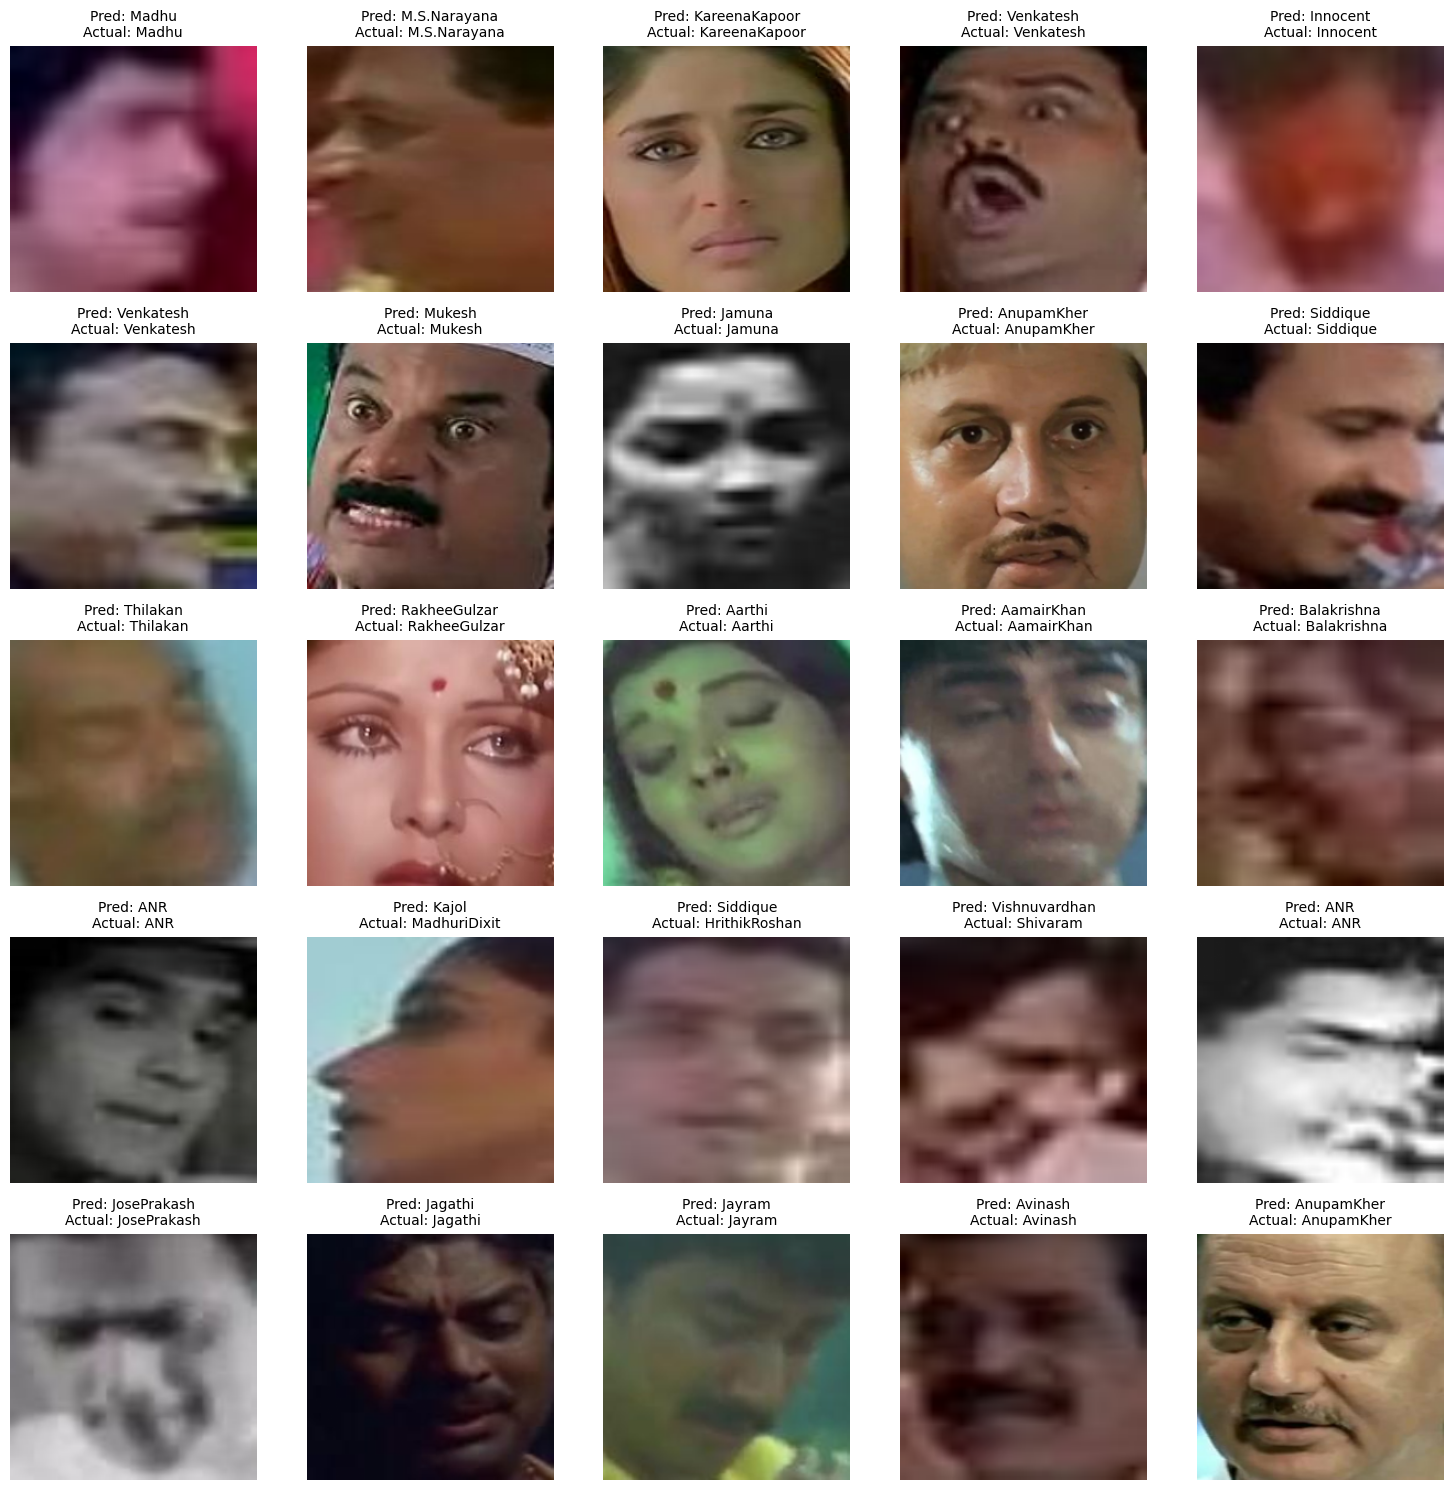

In [26]:
import torch
import matplotlib.pyplot as plt
import random
#Unnormalize for visualization
def unnormalize(img, mean, std):
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return img

# Use the original dataset used for test_loader
test_data = full_dataset
class_names = test_data.classes
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

def predict_and_show_grid(model, test_data, rows=5, cols=4, device="cpu"):
    model.eval()
    fig, axs = plt.subplots(rows, cols, figsize=(15, 15))
    selected_indices = random.sample(range(len(test_data)), rows * cols)

    with torch.no_grad():
        for ax, idx in zip(axs.flatten(), selected_indices):
            x, y = test_data[idx]
            x_input = x.unsqueeze(0).to(device)

            # Predict
            pred = model(x_input)
            predicted = pred.argmax(1).item()

            # Unnormalize for display
            x_display = unnormalize(x.clone(), mean, std).permute(1, 2, 0).cpu()

            # Display image
            ax.imshow(x_display.numpy())
            ax.set_title(f'Pred: {class_names[predicted]}\nActual: {class_names[y]}', fontsize=10)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Call function
predict_and_show_grid(model, full_dataset, rows=5, cols=5, device=device)

In [35]:
import torch
import numpy as np

# Normalization values (used in training)
norm_mean = np.array([0.485, 0.456, 0.406])
norm_std = np.array([0.229, 0.224, 0.225])

def unnormalize(img, mean=norm_mean, std=norm_std):
    """
    Reverses the normalization applied to an image tensor.
    Args:
        img (Tensor): A normalized image tensor (C, H, W)
        mean (array): Mean used for normalization
        std (array): Standard deviation used for normalization
    Returns:
        Unnormalized image tensor
    """
    img = img.clone()  # Avoid modifying the original tensor
    for i in range(img.shape[0]):  # Iterate over channels (C)
        img[i] = img[i] * std[i] + mean[i]
    return torch.clamp(img, 0, 1)  # Clip values to valid range


In [105]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision import datasets
from tqdm import tqdm

# Normalize/Unnormalize helper functions
def unnormalize(tensor):
    """Unnormalize the image using the normalization constants."""
    return tensor * torch.tensor(norm_std).view(3, 1, 1) + torch.tensor(norm_mean).view(3, 1, 1)


In [79]:
def fgsm_attack(image, epsilon, data_grad):
  if epsilon == 0:
    return image
  else:
    image = unnormalize(image)
    pertubed_image = image + epsilon*data_grad.sign()
    pertubed_image = torch.clamp(pertubed_image,0,1)
    pertubed_image = transforms.Normalize(mean = norm_mean, std = norm_std)(pertubed_image)
    return pertubed_image.float()

In [82]:
def fgsm_test(model, data_loader, epsilon, n_examples):
  '''
  input: 
    data_loader: data set, batch size = 1
    epsilon: parameter to perform fgsm attack
  return:
    final_acc: accuracy of the model on classifying adversarial examples created based on datas
    adv_examples: n_examples examples of successed adversrial examples
  '''
  print('Epsilon:', epsilon)
  print('-' * 10)
  correct = 0
  adv_examples = []
  # Loop over all examples in data set, data shape: (C, H, W)
  for i, (data, target) in enumerate(data_loader):

      if i>0 and i%5000 == 0:
        current_acc = correct/i
        print(f'Test Accuracy = {current_acc:.4f} [{i:>5d} / {len(data_loader):>5d}]')

      # Send the data and label to the device
      data, target = data.to(device), target.to(device)

      # Set requires_grad attribute of tensor. Important for Attack
      data.requires_grad = True

      # Forward pass the data through the model
      output = model(data)
      init_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
      # If the initial prediction is wrong, dont bother attacking, just move on
      if init_pred.item() != target.item():
          continue

      # Calculate the loss
      loss = F.nll_loss(output, target)

      # Zero all existing gradients
      model.zero_grad()

      # Calculate gradients of model in backward pass
      loss.backward()

      # Collect datagrad
      data_grad = data.grad.data

      # Call FGSM Attack
      perturbed_data = fgsm_attack(data, epsilon, data_grad)

      # Re-classify the perturbed image
      output = model(perturbed_data)

      # Check for success
      final_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
      if final_pred.item() == target.item():
          correct += 1
          # Special case for saving 0 epsilon examples
          if (epsilon == 0) and (len(adv_examples) < n_examples):
              adv_ex = perturbed_data.squeeze().detach().cpu()
              ori_ex = data.squeeze().detach().cpu()
              adv_examples.append( (init_pred.item(), final_pred.item(), adv_ex, ori_ex) )
      else:
          # Save some adv examples for visualization later
          if len(adv_examples) < n_examples:
              adv_ex = perturbed_data.squeeze().detach().cpu()
              ori_ex = data.squeeze().detach().cpu()
              adv_examples.append( (init_pred.item(), final_pred.item(), adv_ex, ori_ex) )
      


  # Calculate final accuracy for this epsilon
  final_acc = correct/float(len(data_loader))
  print("Epsilon: {}\tTest Accuracy = {} / {} = {} \n".format(epsilon, correct, len(data_loader), final_acc))

  # Return the accuracy and an adversarial example
  return final_acc, adv_examples

In [83]:
epsilons = [0.001, 0.01, 0.02, 0.03, 0.04]  # Updated epsilon values
n_examples = 25
examples = []
accuracies = []

# Run test for each epsilon
for eps in epsilons:
    acc, ex = fgsm_test(model, test_loader_1, eps, n_examples)
    accuracies.append(acc)
    examples.append(ex)


Epsilon: 0.001
----------
Test Accuracy = 0.0004 [ 5000 / 34513]
Test Accuracy = 0.0006 [10000 / 34513]
Test Accuracy = 0.0006 [15000 / 34513]
Test Accuracy = 0.0006 [20000 / 34513]
Test Accuracy = 0.0006 [25000 / 34513]
Test Accuracy = 0.0005 [30000 / 34513]
Epsilon: 0.001	Test Accuracy = 21 / 34513 = 0.0006084663749891346 

Epsilon: 0.01
----------
Test Accuracy = 0.0010 [ 5000 / 34513]
Test Accuracy = 0.0007 [10000 / 34513]
Test Accuracy = 0.0005 [15000 / 34513]
Test Accuracy = 0.0006 [20000 / 34513]
Test Accuracy = 0.0004 [25000 / 34513]
Test Accuracy = 0.0004 [30000 / 34513]
Epsilon: 0.01	Test Accuracy = 16 / 34513 = 0.00046359342856315013 

Epsilon: 0.02
----------
Test Accuracy = 0.0002 [ 5000 / 34513]
Test Accuracy = 0.0002 [10000 / 34513]
Test Accuracy = 0.0003 [15000 / 34513]
Test Accuracy = 0.0004 [20000 / 34513]
Test Accuracy = 0.0004 [25000 / 34513]
Test Accuracy = 0.0003 [30000 / 34513]
Epsilon: 0.02	Test Accuracy = 12 / 34513 = 0.00034769507142236257 

Epsilon: 0.03
----

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42195398..1.8025708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32776785..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3791421..1.0356864].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38770443..0.9485404].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5247024..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..0.8875382].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55038965..1.8

Classes found: ['ANR', 'AamairKhan', 'Aarthi', 'AkshayKumar', 'Ali', 'Ambresh', 'AmitabhBachchan', 'AmrishPuri', 'AnilKapoor', 'Annapoorna', 'AnupamKher', 'Ashwath', 'Avinash', 'BabuMohan', 'Balakrishna', 'Bhanupriya', 'Bharathi', 'BomanIrani', 'Brahmanandam', 'Cochinhaneefa', 'Dileep', 'Dr.Rajkumar', 'Dwarkish', 'FaridaJalal', 'HrithikRoshan', 'Innocent', 'Jagadeesh', 'JagapathiBabu', 'Jagathi', 'Jamuna', 'JayaBhaduri', 'Jayaprakash', 'Jayram', 'JosePrakash', 'K.Viswanath', 'KajalAgarwal', 'Kajol', 'KareenaKapoor', 'KarunaBenerjee', 'KatrinaKaif', 'KavyaMadhavan', 'KotaSrinivasarao', 'Lakshmidevi', 'Leelavathi', 'Loknath', 'M.S.Narayana', 'MadhabiMukherjee', 'Madhavan', 'Madhu', 'MadhuriDixit', 'Mallikarjunrao', 'Mammukoya', 'Mamootty', 'Mohanlal', 'Mukesh', 'NTR', 'Nagarjuna', 'NedumudiVenu', 'PareshRaval', 'Pavithralokesh', 'PrakashRaj', 'Prema', 'PremaNazir', 'RajeshKhanna', 'RakheeGulzar', 'RamanaReddy', 'Ramaprabha', 'RameshArvind', 'Rameshbhatt', 'RamyaKrishna', 'Ranimukherji', 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5178571..1.5411329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2678312..1.7764271].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


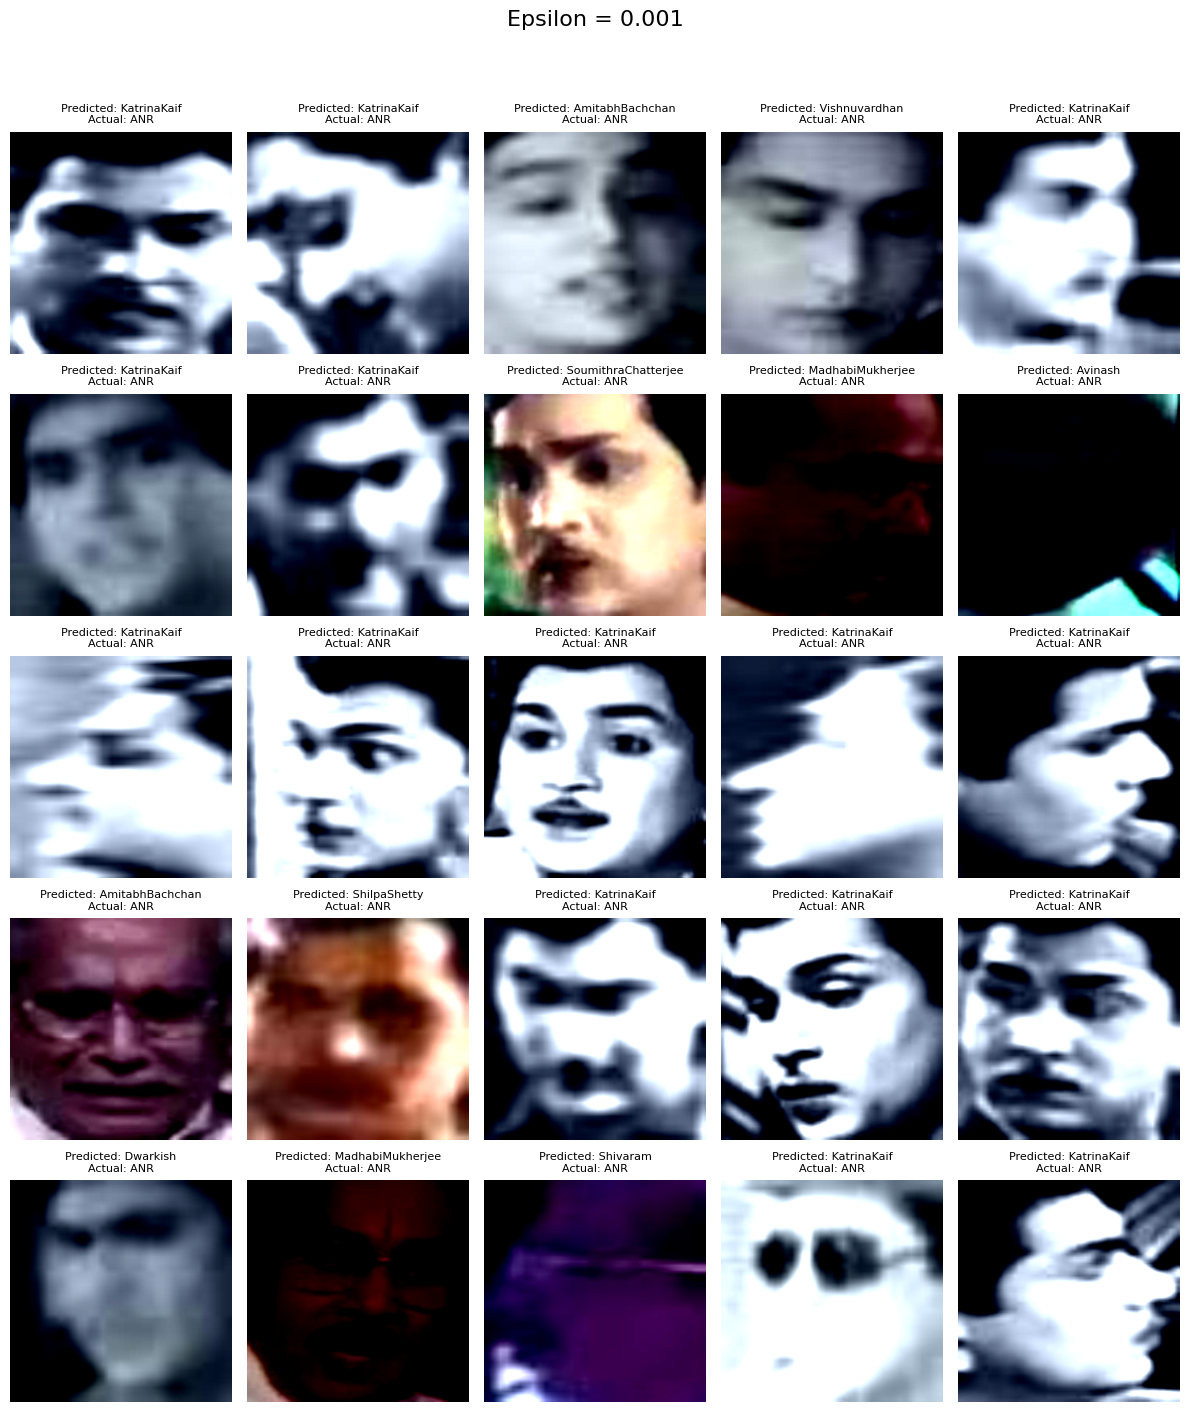

In [116]:


# Ensure your path is correct and raw string is used to avoid unicode errors
extract_path = r'C:\Users\nissy\Desktop\MAJOR\stl10\celeb_data\IMFDB FR dataset\IMFDB FR dataset'

# Assuming transform is defined earlier in your code
full_dataset = datasets.ImageFolder(root=extract_path, transform=transform)
class_names = full_dataset.classes

print(f"Classes found: {class_names}")

# Helper function to safely display image
def ax_imshow(ax, img, predicted_idx, actual_idx):
    img = img / 2 + 0.5  # Reverse normalization
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    
    # Safeguard class name indexing
    predicted_class = class_names[predicted_idx] if predicted_idx < len(class_names) else "Unknown"
    actual_class = class_names[actual_idx] if actual_idx < len(class_names) else "Unknown"
    
    ax.set_title(f'Predicted: {predicted_class}\nActual: {actual_class}', fontsize=8)
    ax.axis('off')

# Check that `examples` list exists and matches epsilon count
if len(examples) != len(epsilons):
    print(f"[Warning] Number of examples ({len(examples)}) doesn't match epsilons ({len(epsilons)}).")
    eps_to_iterate = min(len(examples), len(epsilons))
else:
    eps_to_iterate = len(epsilons)

# Visualize
for i in range(eps_to_iterate):
    epsilon = epsilons[i]
    current_examples = examples[i]

    if not current_examples:
        print(f"[Info] No examples available for epsilon {epsilon}. Skipping...")
        continue

    fig, axs = plt.subplots(5, 5, figsize=(12, 15))
    fig.suptitle(f"Epsilon = {epsilon}", fontsize=16)
    
    for j in range(min(len(current_examples), 25)):
        orig_label_idx, adv_label_idx, adv_ex, ori_ex = current_examples[j]
        ax = axs[j // 5, j % 5]
        ax_imshow(ax, ori_ex, predicted_idx=adv_label_idx, actual_idx=orig_label_idx)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [97]:
def ifgsm_attack(image, epsilon, data_grad, alpha, num_iter):
    # Copy the original image
    perturbed_image = image.clone()

    for i in range(num_iter):
        # Ensure the image is normalized for each iteration
        perturbed_image = unnormalize(perturbed_image)

        # Compute the sign of the gradient
        perturbed_image = perturbed_image + alpha * data_grad.sign()

        # Clip the perturbation to maintain within the allowed epsilon bounds
        perturbation = torch.clamp(perturbed_image - image, min=-epsilon, max=epsilon)
        perturbed_image = image + perturbation

        # Re-normalize the image to maintain its integrity within the input space
        perturbed_image = torch.clamp(perturbed_image, 0, 1)  # Ensure pixel values are valid
        perturbed_image = transforms.Normalize(mean=norm_mean, std=norm_std)(perturbed_image)

    return perturbed_image.float()


In [102]:
def ifgsm_test(model, data_loader, epsilon, n_examples, alpha, num_iter):
    '''
    input: 
      model: the model to test
      data_loader: data set, batch size = 1
      epsilon: maximum perturbation to perform ifgsm attack
      alpha: step size for each iteration of ifgsm
      num_iter: number of iterations for the attack
      n_examples: number of examples to save for visualization
    return:
      final_acc: accuracy of the model on classifying adversarial examples created
      adv_examples: n_examples examples of successful adversarial examples
    '''
    print('Epsilon:', epsilon)
    print('-' * 10)
    correct = 0
    adv_examples = []
    
    # Loop over all examples in the data set, data shape: (C, H, W)
    for i, (data, target) in enumerate(data_loader):
        
        if i > 0 and i % 34513 == 0:
            current_acc = correct / i
            print(f'Test Accuracy = {current_acc:.4f} [{i:>5d} / {len(data_loader):>5d}]')

        # Send the data and label to the device
        data, target = data.to(device), target.to(device)

        # Set requires_grad attribute of tensor. Important for Attack
        data.requires_grad = True

        # Forward pass the data through the model
        output = model(data)
        init_pred = output.max(1, keepdim=True)[1]  # get the index of the max log-probability

        # If the initial prediction is wrong, skip the attack
        if init_pred.item() != target.item():
            continue

        # Calculate the loss
        loss = F.nll_loss(output, target)

        # Zero all existing gradients
        model.zero_grad()

        # Calculate gradients of model in backward pass
        loss.backward()

        # Collect the gradients
        data_grad = data.grad.data

        # Call I-FGSM Attack
        perturbed_data = ifgsm_attack(data, epsilon, data_grad, alpha, num_iter)

        # Re-classify the perturbed image
        output = model(perturbed_data)

        # Check for success
        final_pred = output.max(1, keepdim=True)[1]  # get the index of the max log-probability
        if final_pred.item() == target.item():
            correct += 1
            # Special case for saving 0 epsilon examples
            if (epsilon == 0) and (len(adv_examples) < n_examples):
                adv_ex = perturbed_data.squeeze().detach().cpu()
                ori_ex = data.squeeze().detach().cpu()
                adv_examples.append((init_pred.item(), final_pred.item(), adv_ex, ori_ex))
        else:
            # Save some adversarial examples for visualization later
            if len(adv_examples) < n_examples:
                adv_ex = perturbed_data.squeeze().detach().cpu()
                ori_ex = data.squeeze().detach().cpu()
                adv_examples.append((init_pred.item(), final_pred.item(), adv_ex, ori_ex))

    # Calculate final accuracy for this epsilon
    final_acc = correct / float(len(data_loader))
    print(f"Epsilon: {epsilon}\tTest Accuracy = {correct} / {len(data_loader)} = {final_acc}\n")

    # Return the accuracy and a list of adversarial examples
    return final_acc, adv_examples


In [107]:
epsilons = [0.001]  # Updated epsilon values
n_examples = 25
examples = []
accuracies = []

# Parameters for I-FGSM
alpha = 0.005  # Step size for each iteration
num_iter = 10  # Number of iterations for I-FGSM

# Run test for each epsilon using I-FGSM
for eps in epsilons:
    acc, ex = ifgsm_test(model, test_loader_1, eps, n_examples, alpha, num_iter)
    accuracies.append(acc)
    examples.append(ex)

Epsilon: 0.001
----------
Epsilon: 0.001	Test Accuracy = 3 / 34513 = 8.692376785559064e-05



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42195398..1.8025708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32776785..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3791421..1.0356864].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38770443..0.9485404].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5247024..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..0.8875382].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55038965..1.8

Classes found: ['ANR', 'AamairKhan', 'Aarthi', 'AkshayKumar', 'Ali', 'Ambresh', 'AmitabhBachchan', 'AmrishPuri', 'AnilKapoor', 'Annapoorna', 'AnupamKher', 'Ashwath', 'Avinash', 'BabuMohan', 'Balakrishna', 'Bhanupriya', 'Bharathi', 'BomanIrani', 'Brahmanandam', 'Cochinhaneefa', 'Dileep', 'Dr.Rajkumar', 'Dwarkish', 'FaridaJalal', 'HrithikRoshan', 'Innocent', 'Jagadeesh', 'JagapathiBabu', 'Jagathi', 'Jamuna', 'JayaBhaduri', 'Jayaprakash', 'Jayram', 'JosePrakash', 'K.Viswanath', 'KajalAgarwal', 'Kajol', 'KareenaKapoor', 'KarunaBenerjee', 'KatrinaKaif', 'KavyaMadhavan', 'KotaSrinivasarao', 'Lakshmidevi', 'Leelavathi', 'Loknath', 'M.S.Narayana', 'MadhabiMukherjee', 'Madhavan', 'Madhu', 'MadhuriDixit', 'Mallikarjunrao', 'Mammukoya', 'Mamootty', 'Mohanlal', 'Mukesh', 'NTR', 'Nagarjuna', 'NedumudiVenu', 'PareshRaval', 'Pavithralokesh', 'PrakashRaj', 'Prema', 'PremaNazir', 'RajeshKhanna', 'RakheeGulzar', 'RamanaReddy', 'Ramaprabha', 'RameshArvind', 'Rameshbhatt', 'RamyaKrishna', 'Ranimukherji', 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48189062..0.81782144].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..0.7682165].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5178571..1.5411329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2678312..1.7764271].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


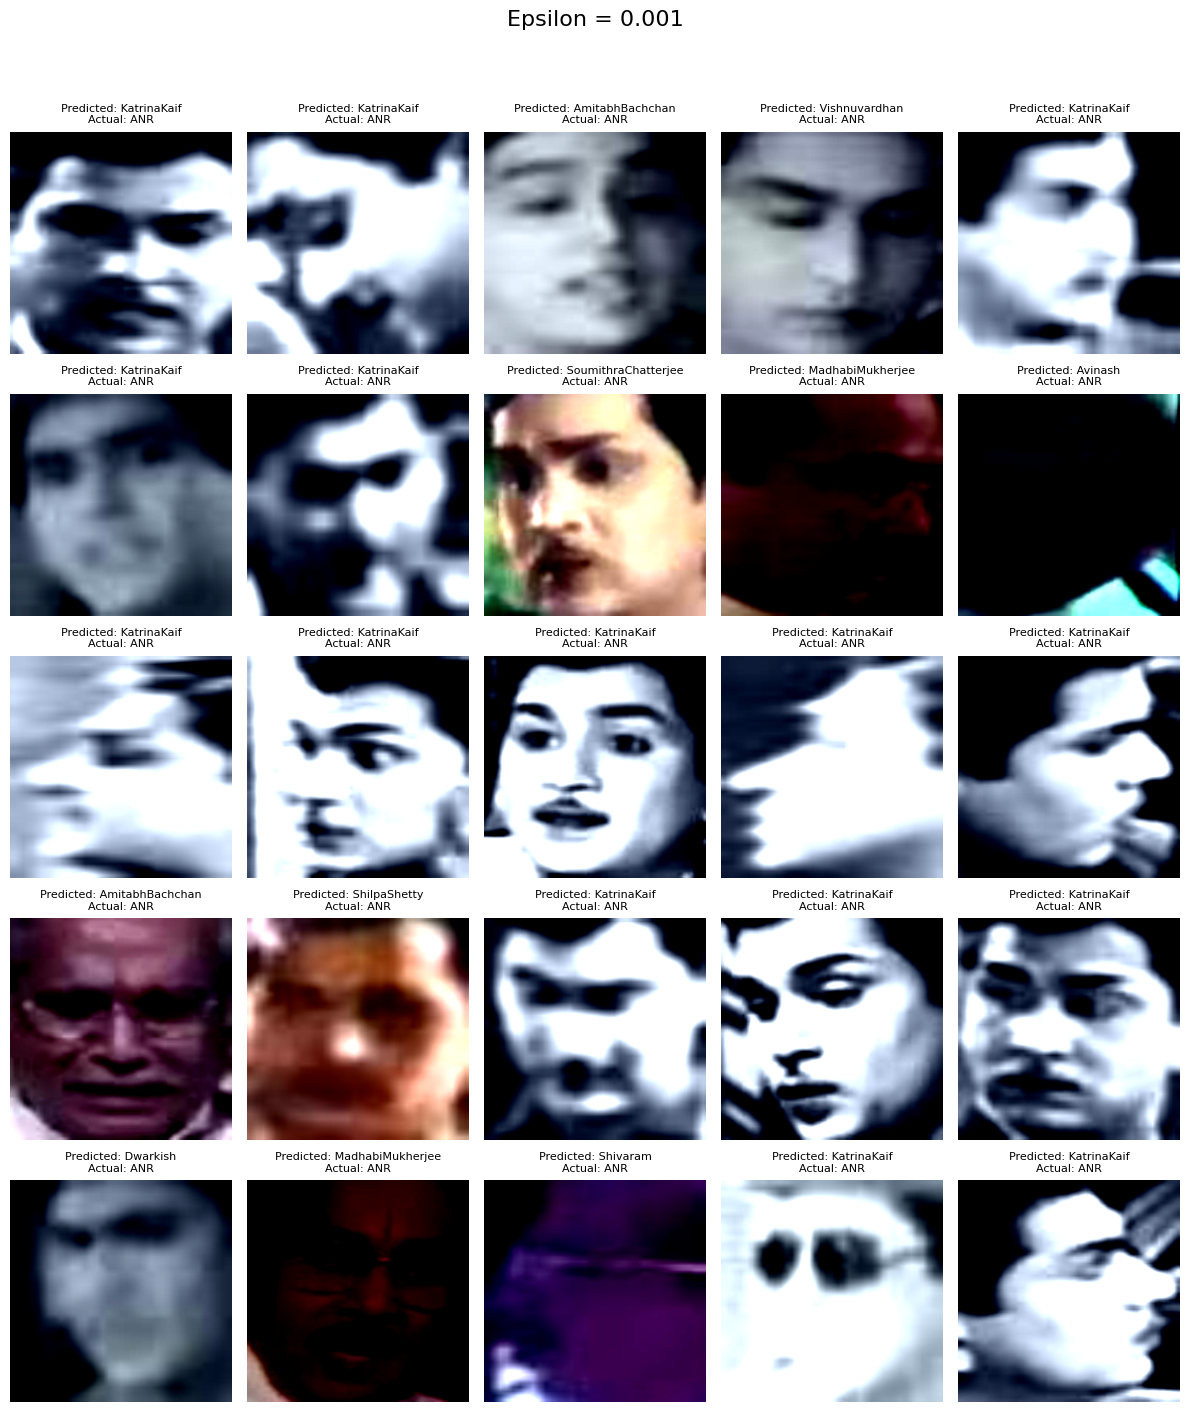

In [117]:


# Ensure your path is correct and raw string is used to avoid unicode errors
extract_path = r'C:\Users\nissy\Desktop\MAJOR\stl10\celeb_data\IMFDB FR dataset\IMFDB FR dataset'

# Assuming transform is defined earlier in your code
full_dataset = datasets.ImageFolder(root=extract_path, transform=transform)
class_names = full_dataset.classes

print(f"Classes found: {class_names}")

# Helper function to safely display image
def ax_imshow(ax, img, predicted_idx, actual_idx):
    img = img / 2 + 0.5  # Reverse normalization
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    
    # Safeguard class name indexing
    predicted_class = class_names[predicted_idx] if predicted_idx < len(class_names) else "Unknown"
    actual_class = class_names[actual_idx] if actual_idx < len(class_names) else "Unknown"
    
    ax.set_title(f'Predicted: {predicted_class}\nActual: {actual_class}', fontsize=8)
    ax.axis('off')

# Check that `examples` list exists and matches epsilon count
if len(examples) != len(epsilons):
    print(f"[Warning] Number of examples ({len(examples)}) doesn't match epsilons ({len(epsilons)}).")
    eps_to_iterate = min(len(examples), len(epsilons))
else:
    eps_to_iterate = len(epsilons)

# Visualize
for i in range(eps_to_iterate):
    epsilon = epsilons[i]
    current_examples = examples[i]

    if not current_examples:
        print(f"[Info] No examples available for epsilon {epsilon}. Skipping...")
        continue

    fig, axs = plt.subplots(5, 5, figsize=(12, 15))
    fig.suptitle(f"Epsilon = {epsilon}", fontsize=16)
    
    for j in range(min(len(current_examples), 25)):
        orig_label_idx, adv_label_idx, adv_ex, ori_ex = current_examples[j]
        ax = axs[j // 5, j % 5]
        ax_imshow(ax, ori_ex, predicted_idx=adv_label_idx, actual_idx=orig_label_idx)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()